In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

In [2]:
X_train = pd.read_csv("telco-data/X_train.csv")
X_test = pd.read_csv("telco-data/X_test.csv")
y_train = pd.read_csv("telco-data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("telco-data/y_test.csv").squeeze("columns")

print(f"X_train: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"X_test:  {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")
X_train.head()

X_train: 5,634 rows x 23 columns
X_test:  1,409 rows x 23 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,tenure_group
0,0,0,1,0,3,1,0,0,0,0,...,1,74.10,1,0,1,0,0,0,1,0
1,1,0,1,0,6,1,0,0,0,0,...,0,25.10,0,1,0,0,1,0,1,0
2,1,0,0,0,31,1,0,1,1,0,...,1,103.45,1,0,0,1,0,0,1,2
3,1,0,1,1,47,1,1,1,1,0,...,1,96.10,1,0,0,1,0,0,0,2
4,0,1,0,0,11,1,0,0,0,0,...,0,89.70,1,0,0,0,0,0,0,0


In [3]:
# Sanity check, just checks that all outputs are 0 and 1, and makes sure that the y train and y test churn rates are similar
y_train = y_train.map({"Yes": 1, "No": 0})
y_test = y_test.map({"Yes": 1, "No": 0})

assert y_train.isna().sum() == 0 and y_test.isna().sum() == 0, "unexpected label found"

print("y_train churn rate:")
print(y_train.value_counts(normalize=True))
print("\ny_test churn rate:")
print(y_test.value_counts(normalize=True))

y_train churn rate:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

y_test churn rate:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Training model

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=47, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",47
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## Making predictions

In [ ]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

pd.DataFrame({"actual": y_test.values, "predicted": y_pred, "churn_probability": y_pred_proba.round(3)}).head(10)

,actual,predicted,churn_probability
0,0,0,0.14
1,1,1,0.58
2,0,1,0.68
3,0,0,0.03
4,0,1,0.64
5,1,0,0.29
6,0,0,0.00
7,1,0,0.45
8,1,0,0.27
9,0,0,0.00


## Evaluating model

### Accuracy (very baseline evaluation)

In [6]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.772


### w/o class_weight = balanced (for now)


##### Precision: measures our model's positive prediction, how correct our model overall. In our context, of everyone PREDICTED to churn, how many actually did? (and for the "No churn" row: of everyone predicted NOT to churn, how many actually didn't?) 
##### Recall: measures our model's ability to find all actual positives. In our context, of everyone who ACTUALLY churned, how many did we correctly predict? (and for the "No churn" row: of everyone actually did NOT churn, how many did we correctly predict as not churning?)
##### F1-score: measures the balance between precision and recall

In [7]:
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.81      0.89      0.85      1035
       Churn       0.60      0.44      0.51       374

    accuracy                           0.77      1409
   macro avg       0.71      0.67      0.68      1409
weighted avg       0.76      0.77      0.76      1409



### ROC-AUC and Confusion matrix 

In [8]:
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.3f}\n")

ROC-AUC:  0.809



If we randomly picked one customer who actually churned and one who actually didn't, our model gives the customer who actually churned a higher predicted churn probability 81% of the time.

#### Plot

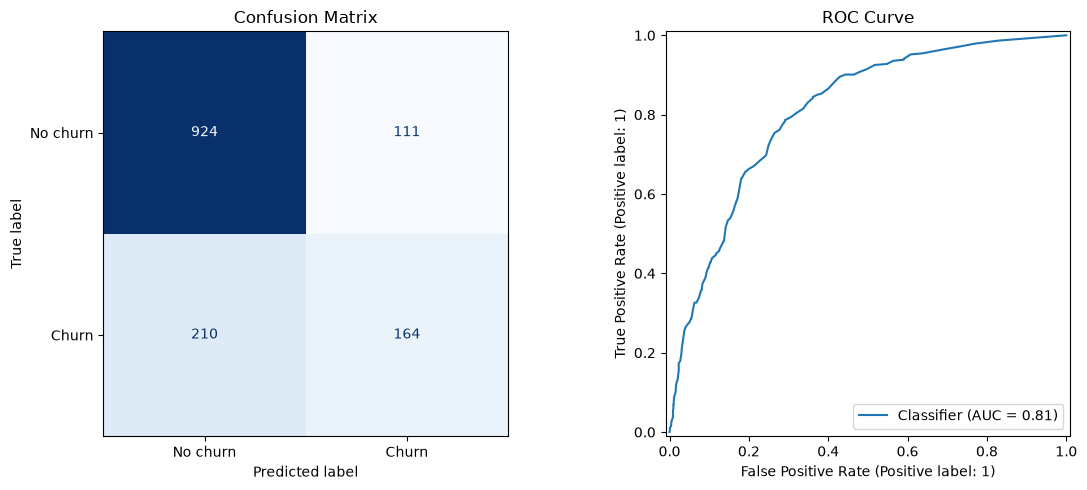

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

The model predicts no churn more accurately than churn. Since only 26.5% of training data are churners, our model would lean more to predicting no churn

### w/ class_weight = balanced

In [11]:
rf_balanced = RandomForestClassifier(
    n_estimators=100, random_state=47, n_jobs=-1, class_weight="balanced"
)
rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)
y_pred_proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_balanced):.3f}\n")
print(classification_report(y_test, y_pred_balanced, target_names=["No churn", "Churn"]))

ROC-AUC: 0.812

              precision    recall  f1-score   support

    No churn       0.86      0.80      0.83      1035
       Churn       0.54      0.65      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



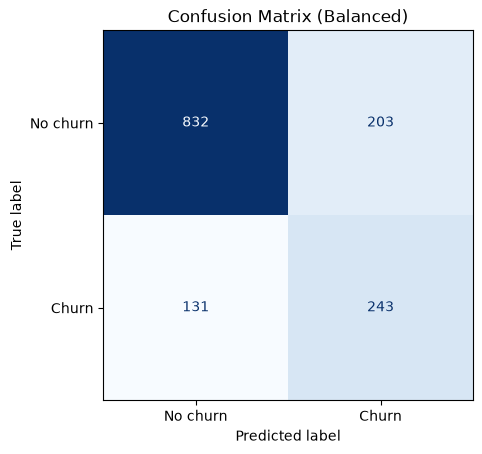

In [12]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
ConfusionMatrixDisplay(cm_balanced, display_labels=["No churn", "Churn"]).plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Comparing `rf` vs `rf_balanced` (Churn class)

| Metric | `rf` (baseline) | `rf_balanced` | Change |
|---|---|---|---|
| Precision | 0.596 | 0.545 | ↓ 0.051 |
| Recall | 0.438 | 0.650 | ↑ 0.212 |
| F1-score | 0.505 | 0.592 | ↑ 0.087 |
| False Negatives | 210 | 131 | ↓ 79 |
| False Positives | 111 | 203 | ↑ 92 |

Balancing the classes catches a lot more real churners but there is more false alarms than before. So it is a tradeoff. However, missing a churner is worse than false alarm bc it is more costly. The company loses revenue if they lose customers with no chance to intervene if it doesn't know they are at risk of leaving.


### Overfitting check

In [13]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Gap:            {train_acc - test_acc:.3f}")

Train accuracy: 0.997
Test accuracy:  0.772
Gap:            0.225


In [ ]:
train_acc_b = rf_balanced.score(X_train, y_train)
test_acc_b = rf_balanced.score(X_test, y_test)
print(f"Train accuracy (balanced): {train_acc_b:.3f}")
print(f"Test accuracy (balanced):  {test_acc_b:.3f}")
print(f"Gap:                       {train_acc_b - test_acc_b:.3f}")


Train accuracy (balanced): 0.991
Test accuracy (balanced):  0.763
Gap:                       0.228


Both `rf` and `rf_balanced` **overfit** and show a large train/test accuracy gap (~0.22+), meaning trees are growing unconstrained and memorizing training data.

Next step tuning:
Possible fixes are constraining tree growth by `max_depth`, `min_samples_leaf`, `min_samples_split`, and/or tune `n_estimators` with cross-validation like `GridSearchCV` to close this gap.